# Bank customer churn prediction

## The problem that's being tackled
The main goal is to indetify the clients that are predisposed to close their banck accounts. It's much harder to sign now clients than it is to keep existing ones, so knowing which clients are more likely to close their accounts in the future, and knowing the main causes for that is of great value.

This project will take the following steps: data analysis ,feature engineering, model comparison and selection and finaly, deploying the best model on an interactive web aplication.

The dataset that will be used: "Bank Customer Churn" available on kaggle: https://www.kaggle.com/datasets/radheshyamkollipara/bank-customer-churn/data

The meaning of each feature in the data set:

* **RowNumber**—corresponds to the record (row) number and has no effect on the output.
* **CustomerId**—contains random values and has no effect on customer leaving the bank.
* **Surname**—the surname of a customer has no impact on their decision to leave the bank.
* **CreditScore**—can have an effect on customer churn, since a customer with a higher credit score is less likely to leave the bank.
* **Geography**—a customer’s location can affect their decision to leave the bank.
* **Gender**—it’s interesting to explore whether gender plays a role in a customer leaving the bank.
* **Age**—this is certainly relevant, since older customers are less likely to leave their bank than younger ones.
* **Tenure**—refers to the number of years that the customer has been a client of the bank. Normally, older clients are more loyal and less likely to leave a bank.
* **Balance**—also a very good indicator of customer churn, as people with a higher balance in their accounts are less likely to leave the bank compared to those with lower balances.
* **NumOfProducts**—refers to the number of products that a customer has purchased through the bank.
* **HasCrCard**—denotes whether or not a customer has a credit card. This column is also relevant, since people with a credit card are less likely to leave the bank.
* **IsActiveMember**—active customers are less likely to leave the bank.
* **EstimatedSalary**—as with balance, people with lower salaries are more likely to leave the bank compared to those with higher salaries.
* **Exited**—whether or not the customer left the bank.
* **Complain**—customer has complaint or not.
* **Satisfaction Score**—Score provided by the customer for their complaint resolution.
* **Card Type**—type of card hold by the customer.
* **Points Earned**—the points earned by the customer for using credit card.

## Libraries used

* **Pandas & NumPy** 
* **Matplotlib & Seaborn** 
* **Scikit-Learn** 
* **XGBoost** 
* **Streamlit** 
* **Joblib** 
* **Kagglehub** 




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
import joblib
import kagglehub
from kagglehub import KaggleDatasetAdapter


file_path = "Customer-Churn-Records.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "radheshyamkollipara/bank-customer-churn",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledfsetadapterpandas
)


print(df.head())



C:\Users\bobei\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\bobei\AppData\Local\Temp\ipykernel_23772\2113075820.py:20: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  Complain  Satisfaction Score Card Type  \
0        101348.88       1         1                   2   DIAMOND   
1        112542.58

## Data Analysis and preliminary assumptions

The dataset has been analysed in multiple ways: has been checked if the data contains Null values, the datatypes of each column have been observed and has been ploted the distribution of of exited/ not exited clients with respect to gender, balance, age etc.

The following tendencies have been obeserved:

* **Rate of churn:** The rate of customers that leave to customers to stay is about 1 to 4
* **Age:** The clients at the age between 45 and 55 have a higher rate of account closure than the younger ones.
* **Number of products:** The clients with 2 products bought tend to be more loyal than the ones with more products.
* **Balance:** There is a very high number of clients that have the balance 0 that tend to not close their accounts
* **Important features** the distributions for Tenure, Estimated Salary and Points Earned are flat, indicationg they're not crucial in predicting whether a client will close their account or not. The important features seem to be Balance, Age, Number of Products


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

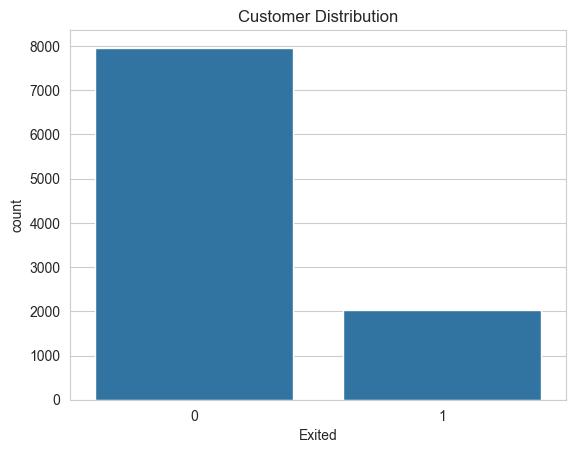


Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Gender
Male      5457
Female    4543
Name: count, dtype: int64

Card Type
DIAMOND     2507
GOLD        2502
SILVER      2496
PLATINUM    2495
Name: count, dtype: int64

Tenure
2     1048
1     1035
7     1028
8     1025
5     1012
3     1009
4      989
9      984
6      967
10     490
0      413
Name: count, dtype: int64
         RowNumber    CustomerId   CreditScore           Age        Tenure  \
count  10000.00000  1.000000e+04  10000.000000  10000.000000  10000.000000   
mean    5000.50000  1.569094e+07    650.528800     38.921800      5.012800   
std     2886.89568  7.193619e+04     96.653299     10.487806      2.892174   
min        1.00000  1.556570e+07    350.000000     18.000000      0.000000   
25%     2500.75000  1.562853e+07    584.000000     32.000000      3.000000   
50%     5000.50000  1.569074e+07    652.000000     37.000000      5.000000   
75%     7500.25000  1.575323e+07    718.00000

In [2]:
# Examining the unique values for cathegorical features and 
# the statistical properties of numerical ones
print(df.info())

print("\nValori lipsa per coloana")
print(df.isnull().sum())

# Number of people that closed the accout vs number of people that didn't
print(df['Exited'].value_counts())

sns.set_style('whitegrid')
plt.figure()
sns.countplot(data=df, x='Exited')
plt.title('Customer Distribution')
plt.show()

print(f"\n{df['Geography'].value_counts()}")
print(f"\n{df['Gender'].value_counts()}")
print(f"\n{df['Card Type'].value_counts()}")
print(f"\n{df['Tenure'].value_counts()}")

print(df.describe())

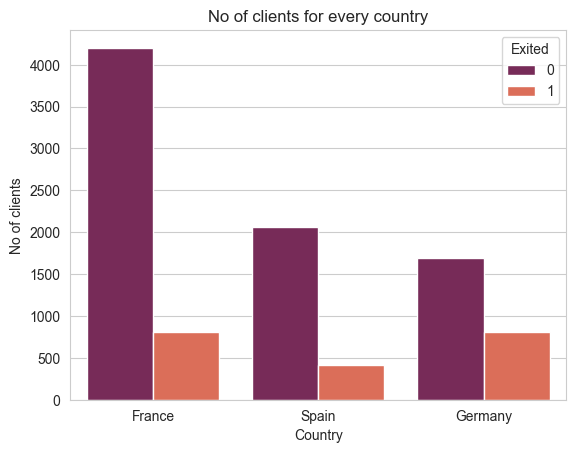

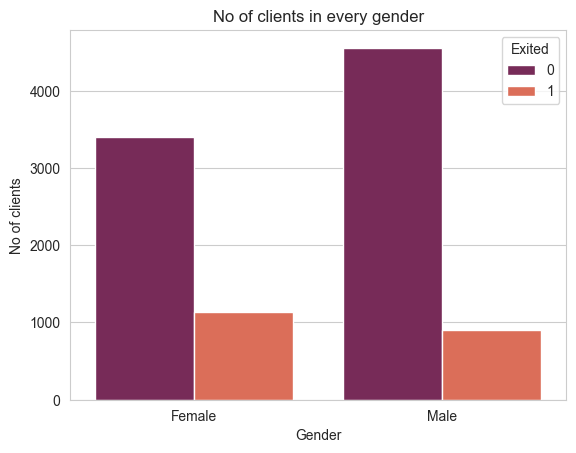

['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'Point Earned']


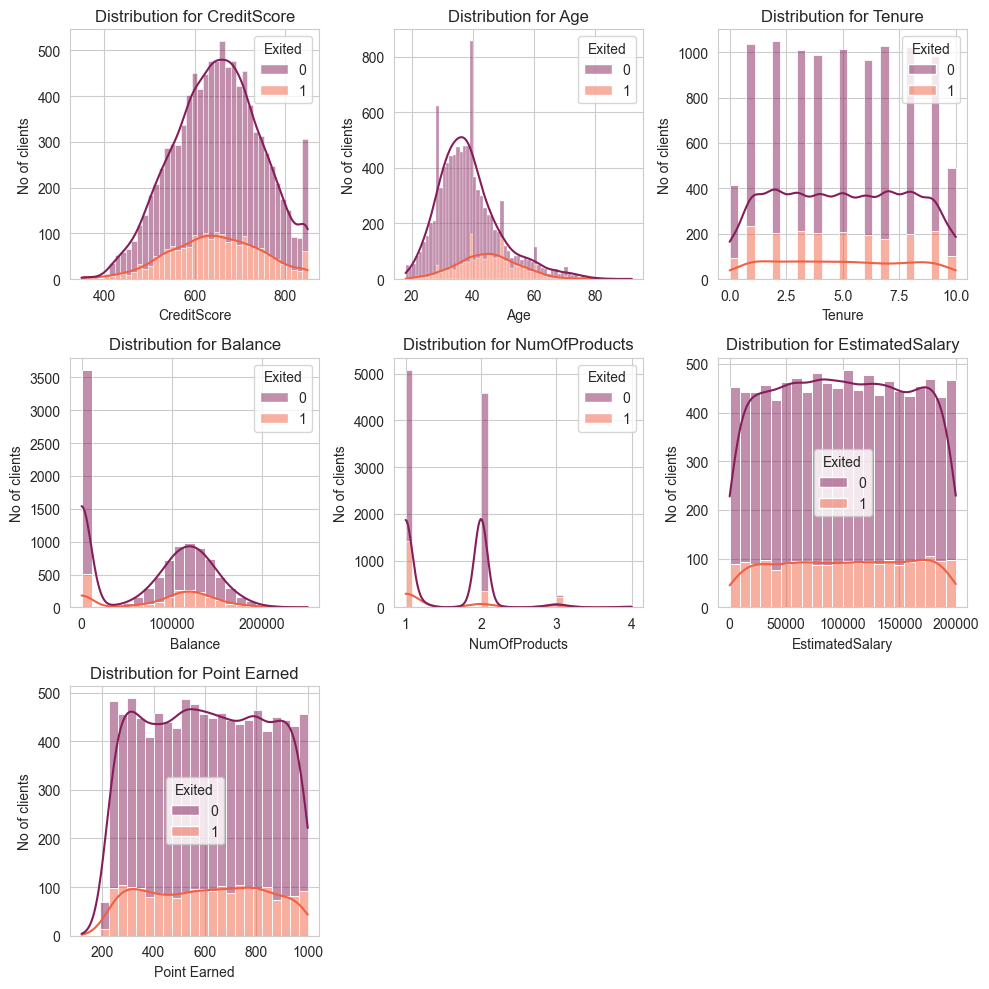

In [3]:
# Plots
plt.figure()
sns.countplot(data=df, x='Geography', hue='Exited', palette='rocket')
plt.title('No of clients for every country')
plt.xlabel('Country')
plt.ylabel('No of clients')
plt.show()

plt.figure()
sns.countplot(data=df, x='Gender', hue='Exited', palette='rocket')
plt.title('No of clients in every gender')
plt.xlabel('Gender')
plt.ylabel('No of clients')
plt.show()

numeric_columns = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'Point Earned']

print(numeric_columns)

plt.figure(figsize=(10, 10))

for index, columnName in enumerate(numeric_columns):
    plt.subplot(3, 3, index + 1)

    sns.histplot(data=df, x=columnName, hue='Exited', multiple='stack', palette='rocket', kde=True, common_norm=False)

    plt.title(f"Distribution for {columnName}")
    plt.xlabel(columnName)
    plt.ylabel('No of clients')
    plt.grid(True)
    
plt.tight_layout()
plt.show()

## Feature Enineering and Pre-processing


The columns RowNumber, CustomerId and Surname don't retain any information about whether a client will leave or not so they are dropped. 
The text features are: Geography, Gender and CardType. Using One-Hot Encoding, they have been transformed in numerical data by replacing each text feature with multiple features that accept only 1s and 0s. For example: the Geography column has been replaced by Geograpy_Germany and Geography_Spain (0 on both of them is considered France).

Than the dataset is split into train and test batches and at the same time ensuring that the same ratio of chured accounts is mentained among training and test sets.

The training and test feature vectors are then scaled to ensure that the mean and standard deviation stay ant 0 and 1 (so that the values are normed and centered on the origin).



In [4]:
uselessColumns = ['RowNumber', 'CustomerId', 'Surname']

df_procesed = df;
df_procesed = df.drop(columns=uselessColumns)
print(df_procesed.head())
df_procesed = pd.get_dummies(df_procesed, columns=['Geography', 'Gender', 'Card Type'], drop_first=True)

df_procesed = df_procesed.astype(int)

print(df_procesed.columns.to_list())

X = df_procesed.drop('Exited', axis=1)
y = df_procesed['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(np.mean(X_test_scaled, axis=0))

   CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619    France  Female   42       2       0.00              1   
1          608     Spain  Female   41       1   83807.86              1   
2          502    France  Female   42       8  159660.80              3   
3          699    France  Female   39       1       0.00              2   
4          850     Spain  Female   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  Complain  \
0          1               1        101348.88       1         1   
1          0               1        112542.58       0         1   
2          1               0        113931.57       1         1   
3          0               0         93826.63       0         0   
4          1               1         79084.10       0         0   

   Satisfaction Score Card Type  Point Earned  
0                   2   DIAMOND           464  
1                   3   DIAMOND           456  
2 

## Identifying data leak after pre-processing

After training and testing a first logistic regression model it's observed that its perdiction scores almost perfect at every indicator. This is an obvious data leak so the weights (coefficients) of every feature are analysed, and it seems that the Complaint feature dominates the rest. We would like to have a model that can determine whether the client is prone to closing their account before filling a complaint. So the Complaint collumn has been dropped, and the model retrained.

Accuracy for Logistic Regression 99.85%
Logistic regression classification report: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1592
           1       1.00      1.00      1.00       408

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



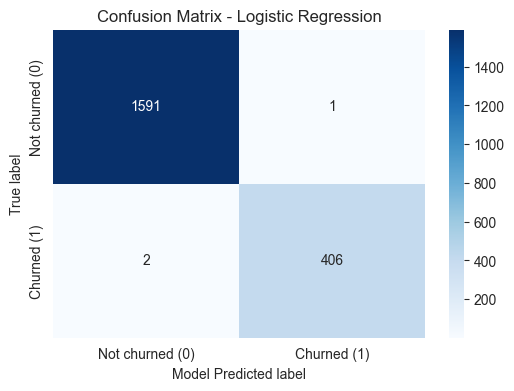

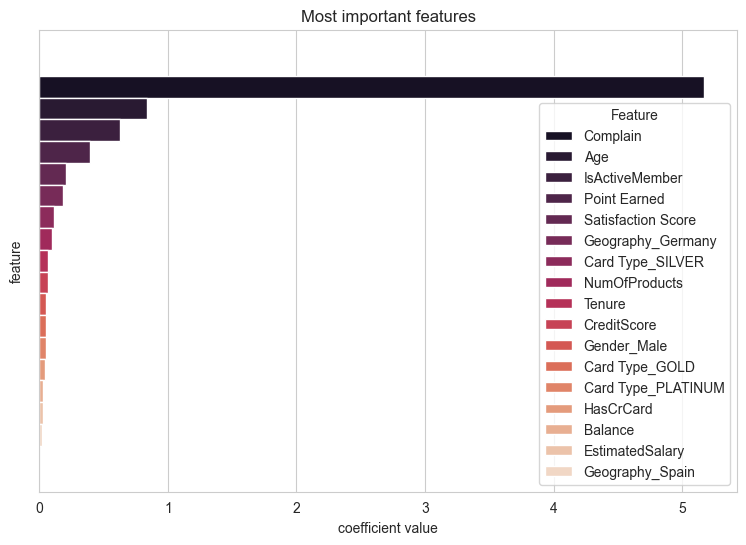

In [5]:
# Logistic regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

yPredLogReg = log_reg.predict(X_test_scaled)

accuracy = accuracy_score(y_test, yPredLogReg)
print(f"Accuracy for Logistic Regression {accuracy*100:.2f}%")

print(f"Logistic regression classification report: \n{classification_report(y_test, yPredLogReg)}")

cm = confusion_matrix(y_test, yPredLogReg)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not churned (0)', 'Churned (1)'], 
            yticklabels=['Not churned (0)', 'Churned (1)'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Model Predicted label')
plt.ylabel('True label')
plt.show()

coef = log_reg.coef_[0]

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': np.abs(coef) 
})

importance = importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(data=importance, x='Importance', hue='Feature', palette='rocket')
plt.title('Most important features')
plt.xlabel('coefficient value')
plt.ylabel('feature')
plt.show()

In [6]:
uselessColumns = ['RowNumber', 'CustomerId', 'Surname', 'Complain']

df_procesed = df;
df_procesed = df.drop(columns=uselessColumns)
#print(df_procesed.head())
df_procesed = pd.get_dummies(df_procesed, columns=['Geography', 'Gender', 'Card Type'], drop_first=True)

df_procesed = df_procesed.astype(int)

#print(df_procesed.columns.to_list())

X = df_procesed.drop('Exited', axis=1)
y = df_procesed['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#print(np.mean(X_test_scaled, axis=0))


## Model Selection

Multiple models have been trained, tested and compared. The #1 indicator was the recall score for the churned customers (because the dataset is imbalanced - so the accuracy can be misleading). The following results have been obtained:

1. **Logistic Regression:** Accuracy: 81%, Recall: 0.21. The model misses 79% of the churned clients
2. **Random Forest (Bagging):** Accuracy: 86.7%, Recall: 0.46. Still 64% of the true positives for churned class are missed.
3. **Multi-Layer Perceptron (Neural Network):** Accuracy: 80.6%, Recall: 0.52. The loss in accuracy indicates that there are more false positives.
4. **XGBoost (Gradient Boosting)** Accuracy: 83.20%, **Recall: 0.64**. The best trade-off for accuracy and recall

Accuracy for Logistic Regression 81.30%
Logistic regression classification report: 
              precision    recall  f1-score   support

           0       0.83      0.97      0.89      1592
           1       0.62      0.21      0.32       408

    accuracy                           0.81      2000
   macro avg       0.73      0.59      0.60      2000
weighted avg       0.79      0.81      0.77      2000



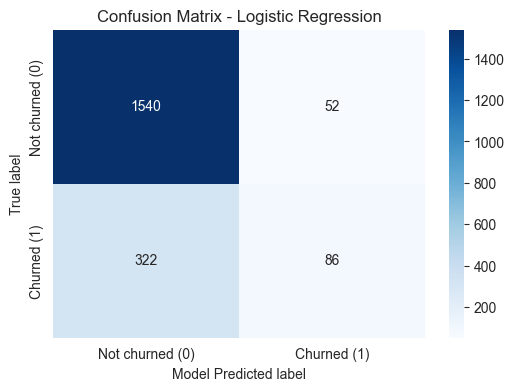

In [7]:
log_reg2 = LogisticRegression(max_iter=1000, random_state=42)
log_reg2.fit(X_train_scaled, y_train)

yPredLogReg = log_reg2.predict(X_test_scaled)

accuracy = accuracy_score(y_test, yPredLogReg)
print(f"Accuracy for Logistic Regression {accuracy*100:.2f}%")

print(f"Logistic regression classification report: \n{classification_report(y_test, yPredLogReg)}")

cm = confusion_matrix(y_test, yPredLogReg)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not churned (0)', 'Churned (1)'], 
            yticklabels=['Not churned (0)', 'Churned (1)'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Model Predicted label')
plt.ylabel('True label')
plt.show()

Accuracy: 86.70%
Classification Report: 
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1592
           1       0.81      0.46      0.58       408

    accuracy                           0.87      2000
   macro avg       0.84      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



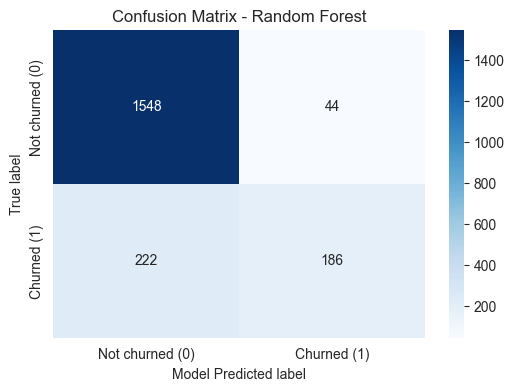

In [8]:
# Random Forest
randomForest = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
randomForest.fit(X_train_scaled, y_train)
yPredRandomForest = randomForest.predict(X_test_scaled)

accuracy = accuracy_score(y_test, yPredRandomForest)
print(f"Accuracy: {accuracy*100:.2f}%")

print(f"Classification Report: \n{classification_report(y_test, yPredRandomForest)}")

cm = confusion_matrix(y_test, yPredRandomForest)

plt.figure(figsize=(6, 4))
# Desenăm matricea sub formă de hartă termică (heatmap)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not churned (0)', 'Churned (1)'], 
            yticklabels=['Not churned (0)', 'Churned (1)'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Model Predicted label')
plt.ylabel('True label')
plt.show()

Accuracy for MLP: 80.60%

Classification Report for MLP:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      1592
           1       0.52      0.52      0.52       408

    accuracy                           0.81      2000
   macro avg       0.70      0.70      0.70      2000
weighted avg       0.81      0.81      0.81      2000



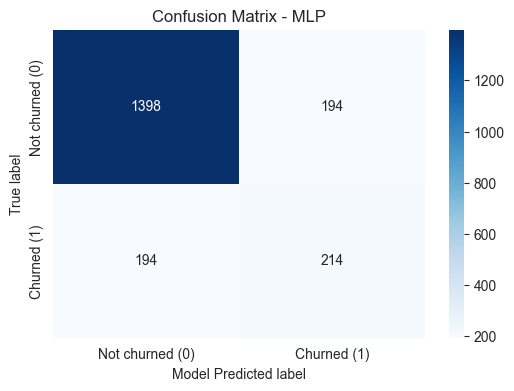

In [9]:
# MLP
mlp_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
mlp_model.fit(X_train_scaled, y_train)
y_pred_mlp = mlp_model.predict(X_test_scaled)

print(f"Accuracy for MLP: {accuracy_score(y_test, y_pred_mlp) * 100:.2f}%\n")
print("Classification Report for MLP:")
print(classification_report(y_test, y_pred_mlp))

cm = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not churned (0)', 'Churned (1)'], 
            yticklabels=['Not churned (0)', 'Churned (1)'])
plt.title('Confusion Matrix - MLP')
plt.xlabel('Model Predicted label')
plt.ylabel('True label')
plt.show()

Accuracy for XGBoost: 83.20%

Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      1592
           1       0.58      0.64      0.61       408

    accuracy                           0.83      2000
   macro avg       0.74      0.76      0.75      2000
weighted avg       0.84      0.83      0.83      2000



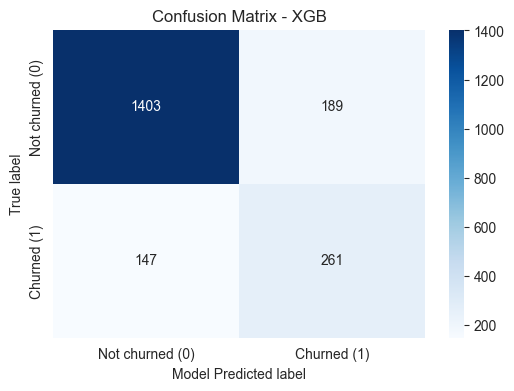

In [10]:
churned = sum(y_train == 1)
not_churned = sum(y_train == 0)
weight = not_churned / churned

xgb_model = xgb.XGBClassifier(
    scale_pos_weight=weight, 
    random_state=42,
    eval_metric='logloss' 
)

xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)

print(f"Accuracy for XGBoost: {accuracy_score(y_test, y_pred_xgb) * 100:.2f}%\n")
print("Classification Report for XGBoost:")
print(classification_report(y_test, y_pred_xgb))

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not churned (0)', 'Churned (1)'], 
            yticklabels=['Not churned (0)', 'Churned (1)'])
plt.title('Confusion Matrix - XGB')
plt.xlabel('Model Predicted label')
plt.ylabel('True label')
plt.show()

## Determining the main causes of churn

We can analyse the most important features that lead to a client leaving the bank using the feature_importances_ attribute of the xgb model object.

By plotting those features from least important to most important we can take the following conlusions:

* The top 3 features that determine churn are: **The number of products** a client bought through the bank, weather the client is an **Active Member**, and the **Age** of the client.

* The bank seems to have a problem keeping clients in **Germany**.

* The type of card, the tenure or the salary don't seem to impact the clients decision tho leave the bank or not, but **Balance** or **Gender** appear to affect itb(although not as much as the top 3).

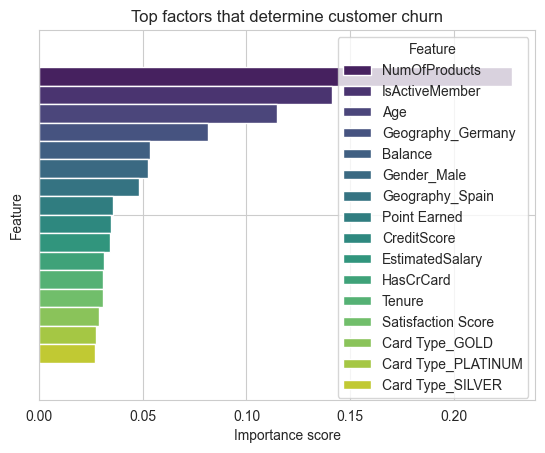

['model_columns.pkl']

In [11]:
importance = xgb_model.feature_importances_

importanceDf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})


ImportanceDf = importanceDf.sort_values(by='Importance', ascending=False)

plt.figure()
sns.barplot(data=ImportanceDf, x='Importance', hue="Feature", palette='viridis')
plt.title('Top factors that determine customer churn')
plt.xlabel('Importance score')
plt.ylabel('Feature')
plt.grid(True)
plt.show()

joblib.dump(xgb_model, 'churn_model_xgb.pkl')
joblib.dump(scaler, 'churn_scaler.pkl')
joblib.dump(X.columns.tolist(), 'model_columns.pkl')